In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [85]:
! pip install --seaborn


[optparse.groups]Usage:[/]   
  pip install \[options] <requirement specifier> \[package-index-options] ...
  pip install \[options] -r <requirements file> \[package-index-options] ...
  pip install \[options] [-e] <vcs project url> ...
  pip install \[options] [-e] <local project path> ...
  pip install \[options] <archive url/path> ...

no such option: --seaborn


In [86]:
import seaborn as sns

In [87]:
df = pd.read_csv('Final Dataset Hb PPG.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn info:")
print(df.info())
print("\nBasic statistics:")
print(df.describe())

Shape: (816, 5)

First 5 rows:
   Red (a.u)  Infra Red (a.u) Gender  Age (year)  Hemoglobin (g/dL)
0   115965.9         105722.9   Male          21               17.5
1   115834.4         105746.7   Male          21               17.5
2   115741.5         105786.0   Male          21               17.5
3   115707.2         105848.1   Male          21               17.5
4   115675.6         105893.5   Male          21               17.5

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Red (a.u)          816 non-null    float64
 1   Infra Red (a.u)    816 non-null    float64
 2   Gender             816 non-null    object 
 3   Age (year)         816 non-null    int64  
 4   Hemoglobin (g/dL)  816 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 32.0+ KB
None

Basic statistics:
           Red (a.u)

In [88]:

print("\nMissing values:")
print(df.isnull().sum())

# Fill missing values if any
df = df.fillna(df.median(numeric_only=True))


Missing values:
Red (a.u)            0
Infra Red (a.u)      0
Gender               0
Age (year)           0
Hemoglobin (g/dL)    0
dtype: int64


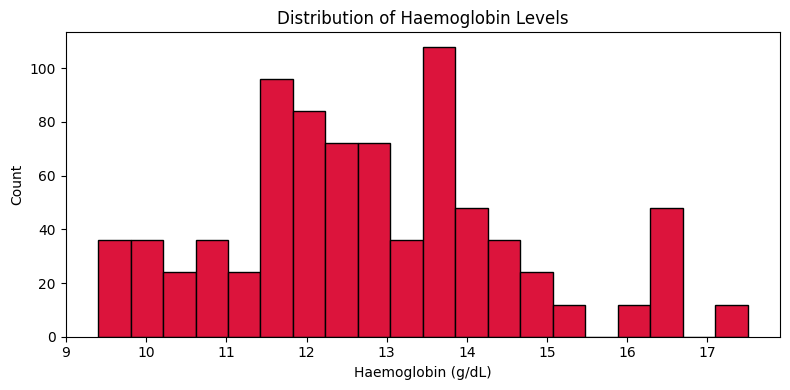

In [89]:
# 2.4 Visualise target variable (Haemoglobin)
plt.figure(figsize=(8,4))
plt.hist(df['Hemoglobin (g/dL)'], bins=20, color='crimson', edgecolor='black')
plt.title('Distribution of Haemoglobin Levels')
plt.xlabel('Haemoglobin (g/dL)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [90]:
df['Gender'] = df['Gender'].map({'Female':0,'Male':1,'Others':2})

In [91]:
#Features and target variable

#Ratio of Red to Infrared (R/IR) 
# is a commonly used feature in PPG signal analysis, 
#especially for estimating blood oxygen saturation (SpO2) and other physiological parameters. 
df['Red_Infra_Ratio'] = df['Red (a.u)']/df['Infra Red (a.u)']


#The Perfusion Index (PI) 
#is a non-invasive, continuous measurement of peripheral blood flow,typically derived from a 
#pulse oximeter's photoplethysmographic (PPG) waveform. 
#It is calculated as the ratio of pulsatile blood flow to non-pulsatile static blood flow
#PI = (AC component / DC component) × 100
df['Perfusion_Index'] = (df['Red (a.u)'] - df['Infra Red (a.u)']) / df['Infra Red (a.u)'] * 100

#SpO2 Estimation
#SpO2 = 110 - 25 × (Red_AC/Red_DC) / (IR_AC/IR_DC)
df['SpO2_Estimate']= 110 - 25 * (df['Red (a.u)'] / df['Red (a.u)'].median()) / (df['Infra Red (a.u)'] / df['Infra Red (a.u)'].median())

print("New features added:")
print(df[['Red_Infra_Ratio', 'Perfusion_Index', 'SpO2_Estimate']].head())


New features added:
   Red_Infra_Ratio  Perfusion_Index  SpO2_Estimate
0         1.096885         9.688535      85.935292
1         1.095395         9.539494      85.967990
2         1.094110         9.410981      85.996185
3         1.093144         9.314385      86.017377
4         1.092377         9.237677      86.034206


In [92]:
# To Remove the Redundant features that may not contribute significantly to the model's 
# performance and could introduce noise or multicollinearity, we can drop the original 
# 'Red (a.u)' and 'Infra Red (a.u)' columns after creating the new features.
df = df.drop(columns=['Perfusion_Index', 'SpO2_Estimate'])

print("Final features after cleanup:", df.columns.tolist())

Final features after cleanup: ['Red (a.u)', 'Infra Red (a.u)', 'Gender', 'Age (year)', 'Hemoglobin (g/dL)', 'Red_Infra_Ratio']


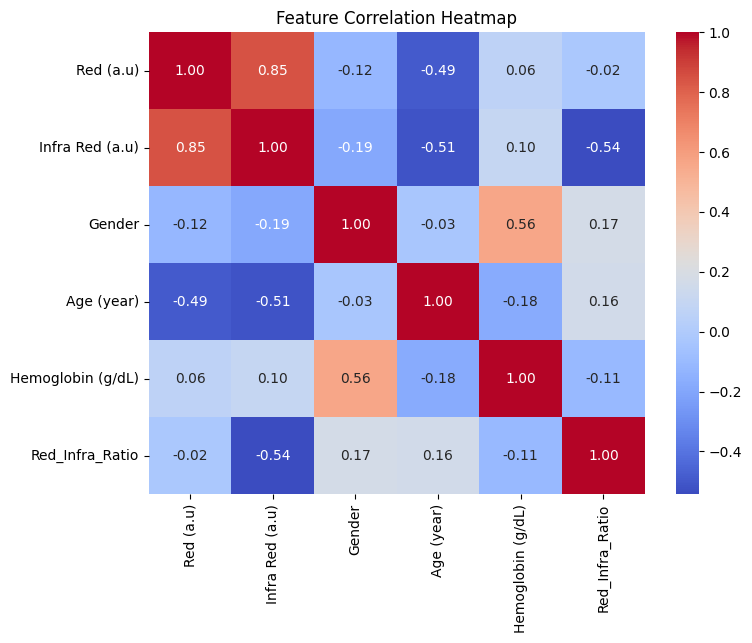

In [93]:
#plot the heatmap to understand which factor affects the Hb most
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f") 
#annot=True to display correlation values, fmt=".2f" to format them to 2 decimal places
#here we are using the 'coolwarm' colormap to visually distinguish positive and negative correlations
#we use df.corr() to compute the correlation matrix of the DataFrame, which includes all numerical
#features and the target variable (Haemoglobin)
plt.title('Feature Correlation Heatmap')
plt.show()

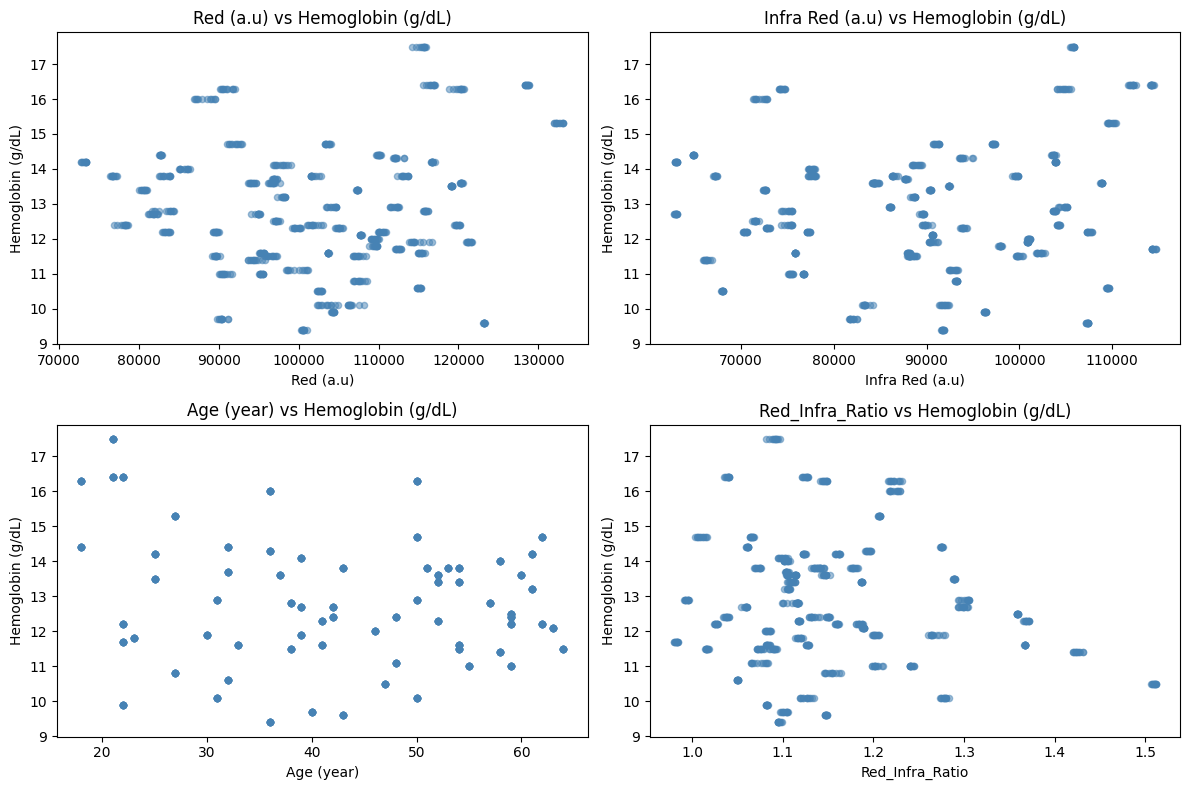

In [94]:

features_to_plot = ['Red (a.u)', 'Infra Red (a.u)', 'Age (year)', 'Red_Infra_Ratio']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    axes[i].scatter(df[feature], df['Hemoglobin (g/dL)'], alpha=0.5, color='steelblue', s=20)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Hemoglobin (g/dL)')
    axes[i].set_title(f'{feature} vs Hemoglobin (g/dL)')

plt.tight_layout()
plt.show()

In [95]:
! pip install scikit-learn

In [96]:
import sys
print(sys.executable)

import numpy
print(numpy.__version__)

c:\Users\shame\AppData\Local\Programs\Python\Python310\python.exe
1.26.4


In [97]:
import numpy
import scipy
import sklearn

print("NumPy:", numpy.__version__)
print("SciPy:", scipy.__version__)
print("Sklearn:", sklearn.__version__)

NumPy: 1.26.4
SciPy: 1.11.4
Sklearn: 1.4.2


In [98]:
from sklearn.model_selection import train_test_split
#this is to split the dataset into training and testing sets, which is a common practice 
# in machine learning to evaluate model performance on unseen data.
from sklearn.preprocessing import StandardScaler
#this is to standardize the features by removing the mean and scaling to unit variance, 
#then we can use it to improve the performance of many machine learning algorithms.
from sklearn.ensemble import RandomForestRegressor
#this is to create a random forest regression model, which is an ensemble learning method 
#that combines multiple decision trees to improve predictive accuracy and control overfitting.
from sklearn.svm import SVR
#this is to create a support vector regression model, which is a type of support vector machine
#that can be used for regression tasks by finding a hyperplane that best fits the data.
from sklearn.linear_model import LinearRegression
#this is to create a linear regression model, which is a simple and widely used algorithm
#for modeling the relationship between a dependent variable and one or more independent variables.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
#these are to evaluate the performance of regression models by calculating metrics such as
#mean absolute error, mean squared error, and R-squared score.



In [99]:
X = df[['Red (a.u)', 'Infra Red (a.u)', 'Gender', 'Age (year)', 'Red_Infra_Ratio']]
y = df['Hemoglobin (g/dL)']

#Train and Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
#this test set are created by randomly splitting the original dataset, where 80% of the data is used for 
#training the model and 20% is reserved for testing its performance on unseen data. The random_state parameter
#ensures that the split is reproducible.
#to show head of testing data
print("\nFirst 5 rows of X_test:")
print(X_test)
#this has colums of red, infrared, age and red/infra ratio, which are the features we will 
# use to predict the haemoglobin levels in the target variable y.
#the formula to find the hemoglobin levels is based on the features we have, and we will train 
# our machine learning models using the training data (X_train and y_train) to learn the relationship 
# between the features and the target variable. After training, we will evaluate the model's performance 
# on the testing data (X_test and y_test) to see how well it can predict haemoglobin levels for new, unseen data.

Training set shape: (652, 5)
Testing set shape: (164, 5)

First 5 rows of X_test:
     Red (a.u)  Infra Red (a.u)  Gender  Age (year)  Red_Infra_Ratio
196   100254.5          91580.5       0          36         1.094714
299   121663.5         100835.8       0          30         1.206551
744   104146.4          96236.9       0          22         1.082188
227    82182.3          63039.7       0          39         1.303659
541    90431.6          81791.2       0          40         1.105640
..         ...              ...     ...         ...              ...
442   120329.0         108765.1       1          37         1.106320
760   109994.7         101190.5       0          46         1.087006
714   123193.2         107355.7       0          43         1.147524
666   119693.6         104112.8       0          42         1.149653
673   107682.5          90658.4       0          63         1.187783

[164 rows x 5 columns]


In [100]:
scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)
#StandardScaler() is to standardize the g=features by removing the mean and scaling to unit variance,
#fit_transford method is to compute the mean and standard deviation of the training data and apply the transformation to tarining data
#transform method is the same but used for the testing data, it uses the mean and standard deviation 
#computed from the training data to ensure that the scaling is consistent between the training and testing sets.
#standardizing the features can help improve the performance of many machine learning algorithms,
#then we can use the scaled features to train our machine learning models and make predictions.

In [101]:
#will train three different regression models: Random Forest, Support Vector Regression (SVR), and Linear Regression,
rf = RandomForestRegressor(n_estimators=100, random_state=42)
svr = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1)
lr = LinearRegression()
rf.fit(X_train_scaled, y_train)
svr.fit(X_train_scaled,y_train)
lr.fit(X_train_scaled, y_train)

print("Models trained successfully!")

Models trained successfully!


In [102]:
#Evaluate the models
models = {'Random Forest' : rf, 'SVR' : svr, 'Linear Regression' : lr }
print("\n{:<20} {:>8} {:>8} {:>8}".format("Model", "MAE", "RMSE", "R²"))
print("-" * 48)

from os import name

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    #print the evaluation metrics for each model in a formatted table using dataframe
    #the format is to align the model name to the left and the metrics to the right with 8 spaces for each metric, 
    # and a header row is printed before the loop to label the columns.
    print(f"{name:<20} {mae:>8.2f} {rmse:>8.2f} {r2:>8.2f}")


#head of test data
print("\nFirst 5 rows of X_test:")
print(X_test.head())

#to get the predicted Hb level by three different models for the head of testing data 
print("\nPredicted vs Actual Haemoglobin Levels for the first 5 test samples:")
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    print(f"\n{name} Predictions:")
    for i in range(5):
        print(f"Predicted: {y_pred[i]:.2f}, Actual: {y_test.iloc[i]:.2f}")




Model                     MAE     RMSE       R²
------------------------------------------------
Random Forest            0.05     0.22     0.98
SVR                      0.36     0.67     0.86
Linear Regression        1.15     1.48     0.31

First 5 rows of X_test:
     Red (a.u)  Infra Red (a.u)  Gender  Age (year)  Red_Infra_Ratio
196   100254.5          91580.5       0          36         1.094714
299   121663.5         100835.8       0          30         1.206551
744   104146.4          96236.9       0          22         1.082188
227    82182.3          63039.7       0          39         1.303659
541    90431.6          81791.2       0          40         1.105640

Predicted vs Actual Haemoglobin Levels for the first 5 test samples:

Random Forest Predictions:
Predicted: 9.40, Actual: 9.40
Predicted: 11.90, Actual: 11.90
Predicted: 9.90, Actual: 9.90
Predicted: 12.70, Actual: 12.70
Predicted: 9.70, Actual: 9.70

SVR Predictions:
Predicted: 10.22, Actual: 9.40
Predicted: 12.40, 

In [103]:
#now we will create a user input function to predict the haemoglobin level based on the features we have
#red, infrared, age and red/infra ratio
def predict_hemoglobin(red, infrared,gender,age):
    red_infra_ratio = red / infrared
    input_data = np.array([[red, infrared, gender, age, red_infra_ratio]])
    input_data_scaled = scalar.transform(input_data)
    
    rf_pred = rf.predict(input_data_scaled)[0]
    #we have the [0] at the end because the predict method returns an array, and we want to get the first (and only) element of that array as our prediction.
    svr_pred = svr.predict(input_data_scaled)[0]
    lr_pred = lr.predict(input_data_scaled)[0]
    
    print(f"Predicted Haemoglobin Levels:")
    print(f"Random Forest: {rf_pred:.2f} g/dL")
    print(f"SVR: {svr_pred:.2f} g/dL")
    print(f"Linear Regression: {lr_pred:.2f} g/dL")
# Example usage:
print("0 for Female, 1 for Male, 2 for Others")
predict_hemoglobin(109871,103519.2,1,18)

0 for Female, 1 for Male, 2 for Others
Predicted Haemoglobin Levels:
Random Forest: 14.40 g/dL
SVR: 14.42 g/dL
Linear Regression: 14.64 g/dL


c:\Users\shame\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [104]:
# Check if model is overfitting
y_train_pred = rf.predict(X_train_scaled)
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae  = mean_absolute_error(y_test,  rf.predict(X_test_scaled))

print(f"Training MAE : {train_mae:.3f}")
print(f"Testing MAE  : {test_mae:.3f}")

if train_mae < 0.1 and test_mae < 0.1:
    print("✅ Consistent — model generalises well")
else:
    print("⚠️ Gap detected — possible overfitting")

Training MAE : 0.011
Testing MAE  : 0.049
✅ Consistent — model generalises well


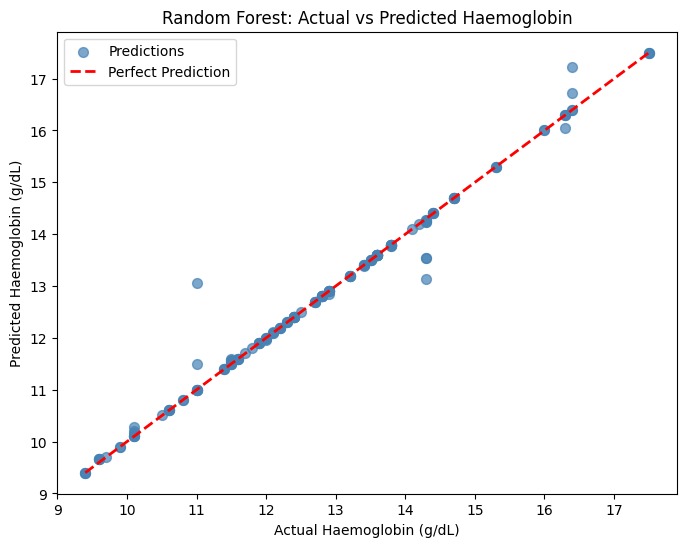

In [105]:
y_pred_rf = rf.predict(X_test_scaled)
#rf.predict is used to generate predictions from the trained Random Forest model using the scaled test features (X_test_scaled).
#this is a built-in method of the RandomForestRegressor class that takes the input features (X_test_scaled) and 
#produces predicted values for the target variable (Haemoglobin levels) based on the patterns learned during training. 
#The resulting predictions are stored in the variable y_pred_rf, which can then be compared to the actual values (y_test) 
# to evaluate the model's performance.
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf, alpha=0.7, color='steelblue', s=50, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Haemoglobin (g/dL)')
plt.ylabel('Predicted Haemoglobin (g/dL)')
plt.title('Random Forest: Actual vs Predicted Haemoglobin')
plt.legend()
plt.show()

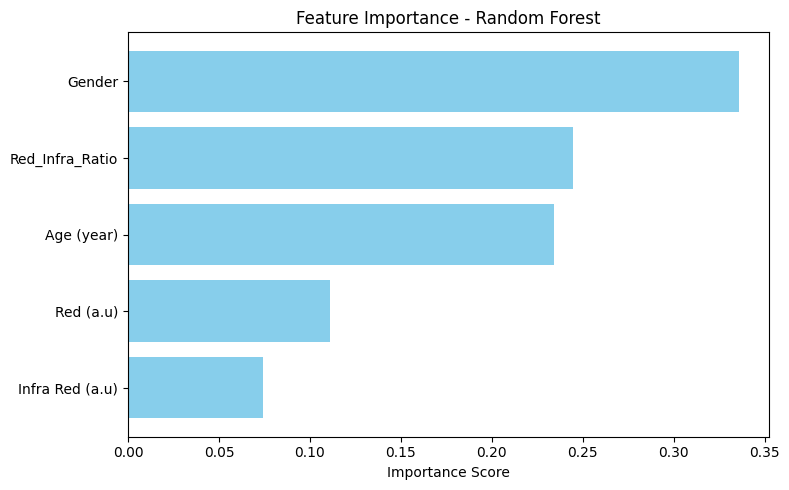

In [106]:
importances = rf.feature_importances_
feature_names = X.columns

plt.figure(figsize=(8,5))
sorted_idx = np.argsort(importances)
plt.barh(feature_names[sorted_idx],  importances[sorted_idx], color='skyblue')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [107]:
y_pred_rf = rf.predict(X_test_scaled)

mae  = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2   = r2_score(y_test, y_pred_rf)

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

MAE  : 0.049
RMSE : 0.221
R²   : 0.985


In [108]:
y_train_pred = rf.predict(X_train_scaled)
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae  = mean_absolute_error(y_test, rf.predict(X_test_scaled))

print(f"Training MAE : {train_mae:.3f}")
print(f"Testing MAE  : {test_mae:.3f}")
print(f"Difference   : {abs(train_mae - test_mae):.3f}")

if abs(train_mae - test_mae) < 0.1:
    print(" No overfitting — model generalises well")
else:
    print(" Possible overfitting — gap is too large")

Training MAE : 0.011
Testing MAE  : 0.049
Difference   : 0.038
 No overfitting — model generalises well


In [109]:
import joblib
joblib.dump(rf, 'hb_model.pkl')
joblib.dump(scalar, 'scalar.pkl')
print("Model saved ")

Model saved 


In [110]:
import joblib
import numpy as np

model  = joblib.load('hb_model.pkl')
scalar = joblib.load('scalar.pkl')

def predict_hb(red, ir, gender, age):
    ratio = red / ir
    features = np.array([[red, ir, gender, age, ratio]])
    scaled   = scalar.transform(features)
    hb       = model.predict(scaled)[0]
    
    if hb >= 12:
        status = "NORMAL"
    elif hb >= 8:
        status = "BORDERLINE ANAEMIC"
    else:
        status = "ANAEMIC"
    
    print(f"Predicted Haemoglobin : {hb:.2f} g/dL")
    print(f"Status                : {status}")

# Examples
predict_hb(red=95000, ir=88000, gender=1, age=25)
predict_hb(red=105000, ir=96000, gender=0, age=45)
predict_hb(red=88000, ir=82000, gender=0, age=60)

Predicted Haemoglobin : 13.82 g/dL
Status                : NORMAL
Predicted Haemoglobin : 11.42 g/dL
Status                : BORDERLINE ANAEMIC
Predicted Haemoglobin : 11.61 g/dL
Status                : BORDERLINE ANAEMIC


c:\Users\shame\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\shame\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\shame\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
